In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from smooth_POD_ROM.post_processing import richardson_lucy, post_process

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.5

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/"

markevery = 100

8.030570172000001


In [21]:
m = 250
x = np.linspace(0, 1, m)

In [22]:
def plot_setup0():
    fig, ax = plt.subplots(figsize=(page_width_in/3, page_width_in/4))
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticklabels([])
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    
    plt.xlabel("x")
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.1, 1.1)
    return fig, ax

In [23]:
def approximate(A, N3):
    coefficients, _, _, _ = np.linalg.lstsq(A, N3, rcond=None)
    #print(coefficients)
    return np.sum(A*coefficients, axis=-1)

In [6]:
def f1(x, mu, w=0.1):
    # original
    y = np.zeros_like(x)
    y[np.abs(x-mu)<(w+1e-6)] = 1
    return y


def f2(x, mu):
    # moving averagee
    y = f1(x, mu)
    k = np.ones((250,))/250
    return np.convolve(y, k, mode='same')


def f3(x, mu, w=0.1, s=0.15):
    # gaussian smoothing
    y = f1(x, mu, w)
    dx = x[1]-x[0]  # 1/m
    y2 = gaussian_filter1d(y, sigma=s/dx)
    return y2


def relative_error(approx, truth):
    abs_error = np.mean((approx-truth)**2)**.5
    return abs_error/np.mean((truth)**2)**.5

In [25]:
def small_figures():
    fig = plt.figure(figsize=(page_width_in, page_width_in/2))
    ax0 = fig.add_axes([0, 0, 1, 1])
    ax0.axis('off')
    
    spacingw = 0.05
    spacingh = 0.1
    w = 1/4-spacingw/4
    h = 1/3-spacingh/3
    
    l1, l2, l3, l4 = 0+spacingw, 1/4+3/4*spacingw, 2/4+2/4*spacingw, 3/4+1/4*spacingw
    b1, b2, b3 = 0, 1/3-spacingh*1/3, 2/3-spacingh*2/3
    
    ax00 = fig.add_axes([l1, b3, w, h])  # [left,bottom,width,height]
    ax01 = fig.add_axes([l2, b3, w, h])
    ax02 = fig.add_axes([l3, b3, w, h])
    ax03 = fig.add_axes([l4, b3, w, h])
    
    ax10 = fig.add_axes([l1, b2, w, h])
    ax11 = fig.add_axes([l2, b2, w, h])
    ax12 = fig.add_axes([l3, b2, w, h])
    ax13 = fig.add_axes([l4, b2, w, h])
    
    ax20 = fig.add_axes([l1, b1, w, h])
    ax21 = fig.add_axes([l2, b1, w, h])
    ax22 = fig.add_axes([l3, b1, w, h])
    ax23 = fig.add_axes([l4, b1, w, h])
    
    axs = np.array([[ax00, ax01, ax02, ax03],
                    [ax10, ax11, ax12, ax13],
                    [ax20, ax21, ax22, ax23]])
    
    for ax_row in axs:
        for ax  in ax_row:
            ax.set_xticks(np.linspace(-1, 1, 5, endpoint=True), minor=False)
            ax.set_yticks(np.linspace(-1, 1, 5, endpoint=True), minor=False)
            ax.set_xticks(np.linspace(-1, 1, 21, endpoint=True), minor=True)
            ax.set_yticks(np.linspace(-1, 1, 21, endpoint=True), minor=True)
            for ticks in [ax.xaxis.get_major_ticks(), ax.xaxis.get_minor_ticks(), ax.yaxis.get_major_ticks(), ax.yaxis.get_minor_ticks()]:
                for tick in ticks:
                    tick.tick1line.set_visible(False)
                    tick.tick2line.set_visible(False)
                    tick.label1.set_visible(False)
                    tick.label2.set_visible(False)
            ax.set_xlim(-0.01, 1.01)
            ax.set_ylim(-0.1, 1.1)
    fontdict = {"ha": "center", "va":"center", "rotation": 0, "fontsize":6}
    ax0.text(1/8+spacingw, b3+h+spacingh/2, "basis functions (BF),\nsmoothed BF dotted\n$\sigma_S=0.1$", fontdict=fontdict)
    ax0.text(3/8+spacingw/4*3, b3+h+spacingh/2, "approximations (red)\nand true solutions,\nsmooth approxim. dotted", fontdict=fontdict)
    ax0.text(5/8+spacingw/4*2, b3+h+spacingh/2, "desmoothed approxim.\nafter 10 and 50 iterations\n$\sigma_D=\sigma_S$", fontdict=fontdict)
    ax0.text(7/8+spacingw/4*1, b3+h+spacingh/2, "desmoothed approxim.\nafter 10 and 50 iterations\n$\sigma_D=2\cdot\sigma_S$", fontdict=fontdict)
    
    fontdict["rotation"] = 90
    ax0.text(spacingw/2, h*5/2, "Case 1:\nBF separated", fontdict=fontdict)
    ax0.text(spacingw/2, h*3/2, "Case 2:\nBF adjacent", fontdict=fontdict)
    ax0.text(spacingw/2, h/2, "Case 3:\nBF overlapping", fontdict=fontdict)
    return fig, axs


0.930 &0.798 &0.879 &1.026 &0.530 &0.218 &\\
0.707 &0.650 &0.575 &0.696 &0.348 &0.198 &\\
0.500 &0.546 &0.356 &0.336 &0.304 &0.128 &\\


C:\Users\florianma\AppData\Local\Temp\ipykernel_20188\631283165.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(pth+"example1.pdf")


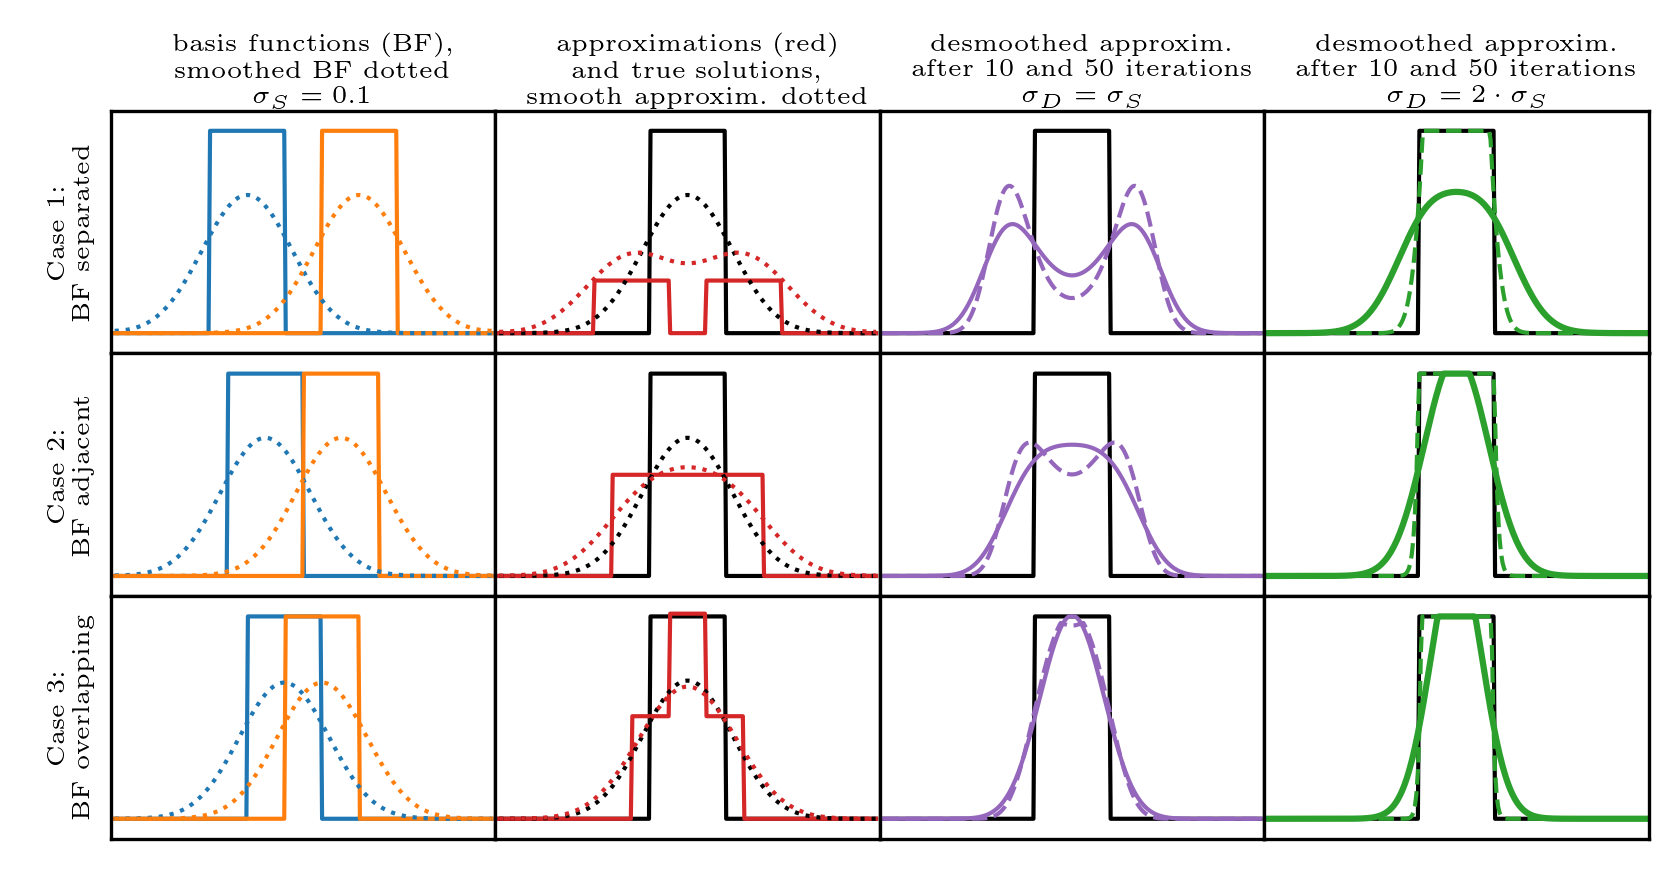

In [26]:
def new_small_figure():
    fig, ax = plt.subplots(1, 1, figsize=(page_width_in/4, page_width_in/4))
    ax.set_xticks(np.linspace(-1, 1, 21, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(-1, 1, 21, endpoint=True), minor=True)
    ax.set_yticklabels([])
    ax.grid(True, which='minor', linestyle='--', lw=.25)
    ax.grid(True, which='major', linestyle='-')
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.1, 1.1)
    return fig, ax


sig = 0.1

# for an error < 1% in case 3, choose sigma = 0.04 and num_iter=1000

fig, axs = small_figures()
for case, d, row in zip(["separated", "adjacent", "overlapping"],
                                    [0.15, 0.1, 0.05], [0, 1, 2]):
    N1 = f1(x, 0.5-d, w=0.1)
    N2 = f1(x, 0.5+d, w=0.1)
    N3 = f1(x, 0.5, w=0.1)
    #print("x1, x2=", 0.5-d, 0.5+d)
    
    A = np.vstack([N1, N2]).T
    N3_hat = approximate(A, N3)
    
    N1_s = f3(x, 0.5-d, w=0.1, s=sig)
    N2_s = f3(x, 0.5+d, w=0.1, s=sig)
    N3_s = f3(x, 0.5, w=0.1, s=sig)
    A = np.vstack([N1_s, N2_s]).T
    N3_s_hat = approximate(A, N3_s)

    N3_D30_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=10, truth=None, damping=2, clip=True, mode="wrap")
    N3_D50_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=50, truth=None, damping=2, clip=True, mode="wrap")
    N3_D100_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=100, truth=None, damping=2, clip=True, mode="wrap")
    
    N3_D30 = richardson_lucy(x, N3_s_hat, sgm=sig*2, num_iter=10, truth=None, damping=2, clip=True, mode="wrap")
    N3_D50 = richardson_lucy(x, N3_s_hat, sgm=sig*2, num_iter=50, truth=None, damping=2, clip=True, mode="wrap")
    N3_D100 = richardson_lucy(x, N3_s_hat, sgm=sig*2, num_iter=100, truth=None, damping=2, clip=True, mode="wrap")

    for N3_hat_xy in [N3_hat, N3_s_hat, N3_D30_, N3_D100_, N3_D30, N3_D100]:
        e = (np.mean((N3_hat_xy-N3)**2)**.5) / np.mean(N3**2)**.5
        print("{:.3f}".format(e), end=" &")
    print("\\\\")

    axs[row, 0].plot(x, N1, "C0", lw=1, label="$N_1$")
    axs[row, 0].plot(x, N2, "C1", lw=1, label="$N_2$")
    axs[row, 0].plot(x, N1_s, "C0:", lw=1, label="$N_{1,S}$")
    axs[row, 0].plot(x, N2_s, "C1:", lw=1, label="$N_{2,S}$")

    axs[row, 1].plot(x, N3, "k-", lw=1, label="$N_3$")
    axs[row, 1].plot(x, N3_hat, "C3-", lw=1, label="$\widehat{N}_3$")
    axs[row, 1].plot(x, N3_s, "k:", lw=1, label="$N_{3,S}$")
    axs[row, 1].plot(x, N3_s_hat, "C3:", lw=1, label="$\widehat{N}_{3,S}$")
    
    axs[row, 2].plot(x, N3, "k-", lw=1, label="$N_3$")
    axs[row, 2].plot(x, N3_D30_, "C4-", lw=1, label="$\widehat{N}_{3,D_{30}}$")
    #axs[row, 2].plot(x, N3_D50_, "C4--", lw=1, label="$\widehat{N}_{3,D_{50}}$")
    axs[row, 2].plot(x, N3_D100_, "C4--", lw=1, label="$\widehat{N}_{3,D_{100}}$")
    
    axs[row, 3].plot(x, N3, "k-", lw=1, label="$N_3$")
    axs[row, 3].plot(x, N3_D30, "C2-", label="$\widehat{N}_{3,D_{30}}$")
    #axs[row, 3].plot(x, N3_D50, "C2--", lw=1, label="$\widehat{N}_{3,D_{50}}$")
    axs[row, 3].plot(x, N3_D100, "C2--", lw=1, label="$\widehat{N}_{3,D_{100}}$")
plt.savefig(pth+"example1.pdf")
plt.show()
    


In [27]:
# c, num_iter = 1.8, 130  # e= 0.118678
# eo = 1
# for c in np.linspace(1, 3, 21):
#     for num_iter in np.arange(10, 500, 10):
#         N3_D500 = richardson_lucy(x, N3_s_hat, sgm=sig*c, num_iter=num_iter, truth=None, damping=2, clip=True, mode="wrap")
#         e = (np.mean((N3_D500-N3)**2)**.5) / np.mean(N3**2)**.5
#         if e < eo:
#             print(c, num_iter, "{:.6f}".format(e), sep="\t")
#             eo = e

In [29]:
n_ds = 100
m = 1000
x = np.linspace(0, 1, m)

distances = np.linspace(0, 0.15, n_ds)
sigmas = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.1]
n_sigmas = len(sigmas)
e1 = np.zeros(n_ds,)
e2 = np.zeros((n_ds, n_sigmas),)
e3 = np.zeros((n_ds, n_sigmas),)
e4 = np.zeros((n_ds, n_sigmas),)
e5 = np.zeros((n_ds, n_sigmas),)
for i, d in enumerate(distances):
    print(i, end=", ")
    N1 = f1(x, 0.5-d, w=0.1)
    N2 = f1(x, 0.5+d, w=0.1)
    N3 = f1(x, 0.5, w=0.1)
    A = np.vstack([N1, N2]).T
    N3_hat = approximate(A, N3)
    e1[i] = np.mean((N3_hat-N3)**2)**.5
    e_min = 100
    sig_opt = 0
    for j, sig in enumerate(sigmas):
        N1_s = f3(x, 0.5-d, w=0.1, s=sig)
        N2_s = f3(x, 0.5+d, w=0.1, s=sig)
        N3_s = f3(x, 0.5, w=0.1, s=sig)
        A = np.vstack([N1_s, N2_s]).T
        N3_s_hat = approximate(A, N3_s)
#         N3_D30_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=10, truth=None, damping=10, clip=True, mode="wrap")
#         N3_D100_ = richardson_lucy(x, N3_s_hat, sgm=sig, num_iter=50, truth=None, damping=10, clip=True, mode="wrap")
#         N3_D30 = richardson_lucy(x, N3_s_hat, sgm=sig*2, num_iter=10, truth=None, damping=10, clip=True, mode="wrap")
        N3_D100 = richardson_lucy(x, N3_s_hat, sgm=sig*2.0, num_iter=1000, truth=None, damping=2, clip=True, mode="wrap")
#         e2[i, j] = np.mean((N3_s_hat-N3)**2)**.5
        e3[i, j] = np.mean((N3_s_hat-N3_s)**2)**.5
#         e4[i, j] = np.mean((N3_D30-N3)**2)**.5
        e5[i, j] = np.mean((N3_D100-N3)**2)**.5

0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 

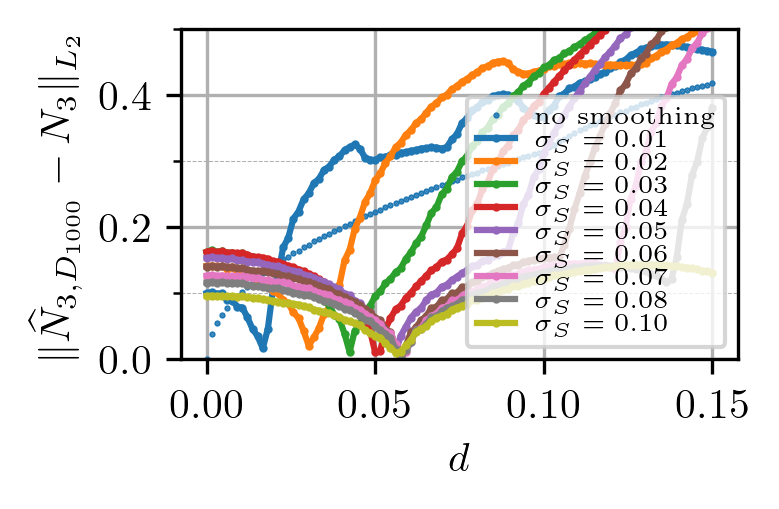

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(page_width_in/2, page_width_in/3))

ax.plot(distances, e1, "C0.", ms=1, label="no smoothing")
for j, sig in enumerate(sigmas[:9]):
    ax.plot(distances, e5[:, j], "o-", ms=1, label="$\sigma_S={:.2f}$".format(sig))

#ax.set_xticks(np.linspace(0, .15, 16, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
#ax.set_yticklabels([])
ax.legend()
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')

plt.xlabel("distance $d$ between $N_1$ and $N_2$")
plt.xlabel("$d$")
plt.ylabel("$\|\widehat{N}_{3,D_{1000}}-N_3\|_{L_2}$")
#plt.xlim(0, 3.)
plt.ylim(0, 0.5)
plt.savefig(pth+"example1_e_vs_d.pdf")
plt.show()

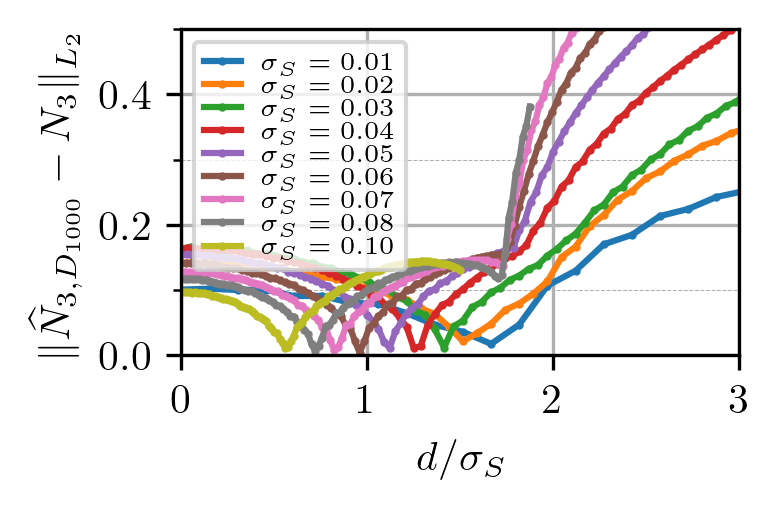

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(page_width_in/2, page_width_in/3))

#ax.plot(distances, e1, "C0.", ms=1, label="no smoothing")
for j, sig in enumerate(sigmas[:9]):
    ax.plot(distances/sig, e5[:, j], "o-", ms=1, label="$\sigma_S={:.2f}$".format(sig))

#ax.set_xticks(np.linspace(0, .15, 16, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
#ax.set_yticklabels([])
ax.legend()
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')

plt.xlabel("distance $d$ between $N_1$ and $N_2$")
plt.xlabel("$d/\sigma_S$")
plt.ylabel("$\|\widehat{N}_{3,D_{1000}}-N_3\|_{L_2}$")
plt.xlim(0, 3.)
plt.ylim(0, 0.5)
plt.savefig(pth+"example1_e_vs_d.pdf")
plt.show()

In [29]:
a = np.arange(20)
np.random.shuffle(a)
a[:5]
np.random.rand(n)

array([0.42359314, 0.13524747, 0.41141812, 0.64796923, 0.13191809,
       0.37453045, 0.2471904 , 0.95735108, 0.30921025, 0.83968101,
       0.57277456, 0.30816503, 0.63965974, 0.78594985, 0.99050989,
       0.78390164, 0.36611892, 0.2897808 , 0.31201644, 0.31958771,
       0.91908072, 0.62580929, 0.20602138, 0.57439465, 0.18158041,
       0.13756114, 0.83415017, 0.06687794, 0.77402502, 0.05218112,
       0.76956356, 0.78091751, 0.72658673, 0.52273869, 0.43446827,
       0.64916485, 0.75763945, 0.73127527, 0.38675563, 0.04453408,
       0.7734661 , 0.23647466, 0.37898535, 0.81472196, 0.9469561 ,
       0.01245019, 0.10568432, 0.17374138, 0.11063794, 0.03724365,
       0.71457854, 0.2406372 , 0.60403101, 0.46978566, 0.48821354,
       0.76637297, 0.90671037, 0.60674609, 0.95047022, 0.52732712,
       0.98524106, 0.16851332, 0.42481317, 0.86053654, 0.01746131,
       0.73254395, 0.61620127, 0.33400458, 0.46036451, 0.91952351,
       0.4505972 , 0.82920914, 0.61667259, 0.7712011 , 0.74404

In [30]:
m2 = 300  # numerb samples in x
x2 = np.linspace(0, 1, m2)
N_max = 150  # max rank
ns = 50  # n samples of N_3 to test
n_trials = 5
_sima_ = 0.015


X_tst1 = np.empty((m2, ns))
X_tst2 = np.empty((m2, ns))
mus = np.linspace(0, 1, ns, endpoint=False)+1/(2*ns)
for j, mu in enumerate(mus):
    X_tst1[:, j] = f1(x2, mu, w=0.01)
    X_tst2[:, j] = f3(x2, mu, w=0.01, s=_sima_)
e0_1 = np.mean(np.mean((X_tst1)**2, axis=0)**.5)
e0_2 = np.mean(np.mean((X_tst2)**2, axis=0)**.5)

NN = np.arange(1, N_max, 1)
eN1 = np.zeros((len(NN), n_trials))
eN2 = np.zeros((len(NN), n_trials))
eN3 = np.zeros((len(NN), n_trials))-1

#mu_rnd_all = x2.copy()#[::2]

for i, n in enumerate(NN):
    for trial in range(n_trials):
        basis1 = np.empty((m2, n))
        basis2 = np.empty((m2, n))
        
#         # random, but unique BF
#         np.random.shuffle(mu_rnd_all)
#         mu_rnd = mu_rnd_all[:n]
        mu_rnd = np.random.rand(n)
        
        for j, mu_j in enumerate(mu_rnd):
            basis1[:, j] = f1(x2, mu_j, w=0.01)
            basis2[:, j] = f3(x2, mu_j, w=0.01, s=_sima_)
        
        coefficients1 = np.zeros((n, ns))
        coefficients2 = np.zeros((n, ns))

        for j, mu in enumerate(mus):
            coefficients1[:, j], _, _, _ = np.linalg.lstsq(basis1, X_tst1[:, j], rcond=None)
            coefficients2[:, j], _, _, _ = np.linalg.lstsq(basis2, X_tst2[:, j], rcond=None)
        approximations1 = basis1 @ coefficients1
        approximations2 = basis2 @ coefficients2
        #if trial==0 and i%2 == 0:
        approximations3 = post_process(x2, approximations2, _sima_, c=2, mu_test=mus[:, None],
                                       mu_train=mu_rnd[:, None], num_iter=200,
                                       shape=(m2,), clip=True, progress=False)
        eN3[i, trial] = np.mean(np.mean((approximations3-X_tst1)**2, axis=0)**.5)
        #print(e3[i], e3[i]/e0_1)
        eN1[i, trial] = np.mean(np.mean((approximations1-X_tst1)**2, axis=0)**.5)
        eN2[i, trial] = np.mean(np.mean((approximations2-X_tst2)**2, axis=0)**.5)
#         for k in range(ns):
#             fig, ax = plt.subplots()
#             ax.plot(x, X_tst1[:, k])
#             ax.plot(x, X_tst2[:, k])
#             ax.plot(x, approximations1[:, k])
#             ax.plot(x, approximations2[:, k])
#             ax.plot(x, approximations3[:, k])
#             plt.show()
    print(n, np.median(eN1[i, :])/e0_1, np.median(eN2[i, :])/e0_2,  np.median(eN3[i, :])/e0_1)
# 10: 0.37
# 50: 0.15
# 100: 0.065
# 200: 0.047
# 500: 0.045
# 1000: 0.046

1 0.99376330068164 0.9728445817740037 1.0036305723909542
2 0.9854166980628943 0.9447033590750068 1.0060342800437907
3 0.9783022832747965 0.9169040434132181 1.000488979407391
4 0.9591799987445342 0.8864658279677847 0.9861115634602687
5 0.9490779651863132 0.8571515078252034 0.9698988028669557
6 0.9544862193530722 0.8368981611815709 0.9600900769189096
7 0.9374690704701959 0.8133468378114341 0.9674756708503438
8 0.9452332386648603 0.799093489394067 0.9076583619276846
9 0.9138346868028054 0.7616761785719088 0.9223496526758325
10 0.911585670936021 0.7260329303094541 0.8616857399403752
11 0.9094553282119556 0.719692805605592 0.8768507813123078
12 0.8836482645645666 0.688101354062593 0.8736938849741254
13 0.8769533676842997 0.6704256175875273 0.833069534230528
14 0.8731520843941407 0.659501852716306 0.8505981783995289
15 0.8833269904917792 0.6182366074051853 0.7926773775046325
16 0.8614960117588153 0.6195590892911874 0.7178731445820514
17 0.8422481918043512 0.5728184958168525 0.750759330838556

133 0.34338156670946857 0.0002141116290774584 0.06044853654532935
134 0.3335378881030771 0.0003671421863834553 0.06043085795065098
135 0.3166114476839207 0.0004302063635325799 0.06184350778517908
136 0.31388471503076537 0.00045150584677406476 0.05979766633407017
137 0.33979487613087733 0.00010130230039570286 0.05837654878420374
138 0.34391968967966735 0.00015856374010324753 0.06126443556817573
139 0.3502727154766642 6.0188485477301874e-05 0.058955995217748705
140 0.31423888574115044 6.953054647008139e-05 0.06007678688478175
141 0.34621103817401266 0.0004741616693276421 0.05891039120930167
142 0.33531808703262067 7.913201813266369e-05 0.06196228393981202
143 0.33721394738376753 0.0002471284594396019 0.059133768020017505
144 0.3165675947475167 3.622960726949776e-05 0.05905595167976714
145 0.3246333713749003 8.356826402089263e-05 0.06113156320276468
146 0.27887753994048126 3.725908017378573e-05 0.05845840703899899
147 0.30645314038431976 3.24937430600561e-05 0.05881110797223194
148 0.3601

In [33]:
print(eN1.shape, NN.shape)
np.save(pth+"/NN.npy", NN)
np.save(pth+"/eN1.npy", eN1)
np.save(pth+"/eN2.npy", eN2)
np.save(pth+"/eN3.npy", eN3)

# NN = np.load(pth+"/NN.npy")
# eN1 = np.load(pth+"/eN1.npy")
# eN2 = np.load(pth+"/eN2.npy")
# eN3 = np.load(pth+"/eN3.npy")
# e0_1 = np.mean(np.mean((X_tst1)**2, axis=0)**.5)
# e0_2 = np.mean(np.mean((X_tst2)**2, axis=0)**.5)

(149, 5) (149,)


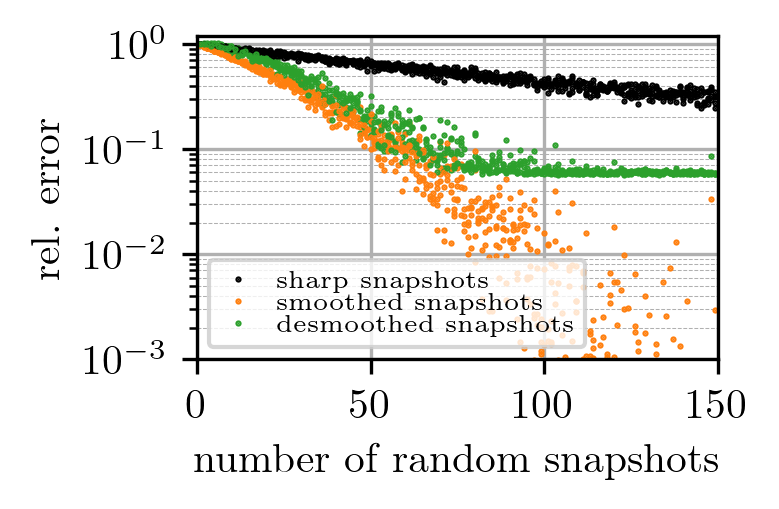

[99.334132   98.31569131 97.35700299 96.13651857 94.67686841 95.13578906
 94.00523084 93.72562404 91.67573585 90.52186716 90.45810741 88.86697237
 87.51803061 87.79966198 87.93011743 85.55434968 84.80623738 85.12429573
 84.65666043 84.09243181 82.74136889 80.29093371 81.72612999 80.43159805
 79.02776708 78.12375836 78.77502338 77.60005329 77.26351436 77.47704104
 75.96125574 73.89085862 74.6729067  74.15553537 75.06229643 72.96014057
 70.82135325 68.82325089 68.94516282 69.70280768 67.41555894 70.40336568
 66.83055504 68.67229485 67.40248817 65.99020332 65.89209485 63.67240924
 64.73587122 64.59012967 62.63177248 62.11707781 63.21089061 61.59269652
 62.78978132 59.72298359 60.87597139 62.38327018 58.31399115 57.4057031
 58.8436093  59.05227882 57.98859054 57.21410973 57.1929061  55.28413969
 56.83863901 55.03644197 53.21698272 52.96802812 53.62796203 54.9218054
 54.24853689 53.28402988 53.79799194 51.37115531 51.29307189 50.77665856
 54.43495294 53.72777449 49.24618091 49.00269132 48.7

In [31]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax.plot(0, e0_1/e0_1, "k.", ms=1, label="sharp snapshots")
ax.plot(0, e0_2/e0_2, "C1.", ms=1, label="smoothed snapshots")
ax.plot(0, e0_1/e0_1, "C2.", ms=1, label="desmoothed snapshots")

for trial in range(n_trials):
    ax.plot(NN, eN1[:, trial]/e0_1, "k.", ms=1)
    ax.plot(NN, eN2[:, trial]/e0_2, "C1.", ms=1)
    ax.plot(NN, eN3[:, trial]/e0_1, "C2.", ms=1)
#    ax.plot(NN, e3[:, trial]/e0_1, "C2.", ms=1)
# ax.plot(np.r_[0, NN], np.r_[1, np.median(e1/e0_1, axis=-1)], "k--", lw=1)
# ax.plot(np.r_[0, NN], np.r_[1, np.median(e2/e0_2, axis=-1)], "C1--", lw=1)
# ax.plot(np.r_[0, NN], np.r_[1, np.median(e3/e0_1, axis=-1)], "C2--", lw=1)
#ax.plot(NN, np.mean(e3/e0_1, axis=-1), "C2--", ms=1)

ax.grid()
#ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_xticks(np.linspace(0, 100, 11, endpoint=True), minor=True)
#ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
#ax.grid(True, which='both')
ax.set_ylim([1e-3, 1.2])
ax.set_xlim([0, 150])
#ax.set_xlim([10, 100])
#ax.set_xticklabels(["", "10", "20", "30", "", "50", "", "", "", "", "100"], minor=True)
ax.set_xlabel("number of random snapshots")
ax.set_ylabel("rel. error")
plt.legend()

plt.savefig(pth+"1st_ex_decay_v3.pdf")
plt.show()
np.set_printoptions(suppress=True)
print(np.mean(eN1/e0_1, axis=-1)*100)
print(np.mean(eN2/e0_2, axis=-1)*100)


In [ ]:
asd

In [ ]:
for j, mu in enumerate(mus):
    if j%15 == 0:
        plt.plot(x, X_tst1[:, j])
        plt.plot(x, X_tst2[:, j], ls="--")

In [ ]:
np.logspace(-6, 1, 5, endpoint=True)

In [ ]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax.plot(0, e0_1/e0_1, "k.", ms=1)
ax.plot(0, e0_2/e0_2, "C1.", ms=1)

for trial in range(n_trials):
    ax.plot(NN, e1[:, trial]/e0_1, "k.", ms=1)
    ax.plot(NN, e2[:, trial]/e0_2, "C1.", ms=1)
#    ax.plot(NN, e3[:, trial]/e0_1, "C2.", ms=1)
ax.plot(np.r_[0, NN], np.r_[1, np.median(e1/e0_1, axis=-1)], "k--", ms=1)
ax.plot(np.r_[0, NN], np.r_[1, np.median(e2/e0_2, axis=-1)], "C1--", ms=1)
#ax.plot(NN, np.mean(e3/e0_1, axis=-1), "C2--", ms=1)

ax.grid()
ax.set_xlim([-5, 205])
ax.set_ylim([1e-6, 2])
ax.set_yscale('log')
ax.set_xticks(np.linspace(0, 200, 21, endpoint=True), minor=True)
ax.set_yticks(np.logspace(-6, 0, 7, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.show()
np.set_printoptions(suppress=True)
print(np.mean(e1/e0_1, axis=-1)*100)
print(np.mean(e2/e0_2, axis=-1)*100)

In [ ]:
asd

In [ ]:
approximations *= 0
e = np.mean((X_tst)**2, axis=0)**.5
print(e)
print(n, np.mean(e))

In [ ]:
asd

In [ ]:
def pulse(x, mu, w=0.1+1e-6):
    y = np.zeros_like(x, dtype=np.float64)
    y[((0+1e-6) < (x-mu)) & ((x-mu) < (w-1e-6))] = 1.0
    mu2 = mu+1
    y[((0+1e-6) < (x-mu2)) & ((x-mu2) < (w-1e-6))] = -1.0
    mu3 = mu-1
    y[((0+1e-6) < (x-mu3)) & ((x-mu3) < (w-1e-6))] = -1.0
    mu4 = mu-2
    y[((0+1e-6) < (x-mu4)) & ((x-mu4) < (w-1e-6))] = 1.0
    return y

from smooth_POD_ROM.pre_processing import smoothen

In [ ]:
fig, axg1 = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
fig, axs1 = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
fig, axg2 = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
fig, axs2 = plt.subplots(figsize=(page_width_in/2, page_width_in/3))

for n in [10, 20, 30, 1000]:
    x = np.linspace(-1, 2, 3*m, endpoint=False) + 1/2*(1/m)
    mu = np.linspace(0, 2, n, endpoint=False) #+ 1/2*(2/n)
    print(x[0], x[-1])
    print(x[0]-(-1), 2-x[-1])
    print("mu")
    print(mu[0], mu[-1])
    print(mu[0], 2-mu[-1])
    print(n)
    
    X = np.empty((3*m, n))
    for j, mu_j in enumerate(mu):
        y = pulse(x, mu_j)
        X[:, j] = y

    dx = 1/m
    Xs = smoothen(X, sigma=0.1/dx, shape=(3*m,), truncate=8, mode="wrap")
    X = X[m:-m]
    Xs = Xs[m:-m]
    x = x[m:-m]
    Ug, Sg, Vg = np.linalg.svd(X, full_matrices=False)
    Us, Ss, Vs = np.linalg.svd(Xs, full_matrices=False)

    fig, ax = plt.subplots()
    ax.plot(x, X[:, 0], "o-")
    ax.plot(x, X[:, 1], "o-")
    ax.plot(x, X[:, -1], "o-")
    #ax.set_xlim([.04, .06])
    
    Ug[:, np.mean(Ug, axis=0)<0] *= -1
    Us[:, np.mean(Us, axis=0)<0] *= -1
    if np.mean(Ug[:, 0])>np.mean(Ug[:, 1]):
        tmp = Ug[:, 0].copy()
        Ug[:, 0] = Ug[:, 1].copy()
        Ug[:, 1] = tmp.copy()
    if np.mean(Us[:, 0])>np.mean(Us[:, 1]):
        tmp = Us[:, 0].copy()
        Us[:, 0] = Us[:, 1].copy()
        Us[:, 1] = tmp.copy()
    axg1.plot(x, Ug[:, 0], ".-", ms=1, label="$n_{\mu}=%i$"%n)
    axs1.plot(x, Us[:, 0], ".-", ms=1, label="$n_{\mu}=%i$"%n)
    axg2.plot(x, Ug[:, 1], ".-", ms=1, label="$n_{\mu}=%i$"%n)
    axs2.plot(x, Us[:, 1], ".-", ms=1, label="$n_{\mu}=%i$"%n)
for ax in [axg1, axs1, axg2, axs2]:
    ax.set_xticks(np.linspace(-1., 1., 21, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(-.2, .2, 21, endpoint=True), minor=True)
    ax.grid(True, which='minor', linestyle='--', lw=.25)
    ax.grid(True, which='major', linestyle='-')
    ax.legend()
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.15, 0.15)
#axs1.set_ylim(-0.15, 0.15)
plt.show()